# **Student Pass/Fail Prediction with ML**

Predicting whether a student **passes or fails** an exam using study habits, lifestyle and demographic data (100,000 students, 44 features).

**Goal:** Build and compare multiple ML models (baseline → advanced) to classify `pass_status` (Pass/Fail).

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Preprocessing & modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)

## **1. Load the Data**

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mobeenfatimah/student-exam-performance-and-success-dataset/student_exam_performance.csv")
print("Shape:", df.shape)
df.head()

Shape: (100000, 44)


,student_id,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,attendance_percentage,assignment_completion_rate,class_participation,study_hours_per_day,self_study_hours,private_tuition,online_learning_hours,study_consistency,study_environment,study_method,revision_frequency,practice_tests_completed,notes_quality,sleep_hours,sleep_quality,daily_screen_time,physical_activity_hours,break_frequency,stress_level,motivation_level,internet_access,device_availability,educational_app_usage,online_course_hours,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,exam_score,performance_grade,pass_status,performance_level
0,STU_000001,20,Female,High School,Public,Middle,NaN,Rural,78.36,2.95,81.49,65.18,Medium,4.94,2.63,0,1.75,Medium,Moderate,Flashcards,Rarely,8,Average,6.31,Excellent,3.80,0.93,Frequently,10,High,1,Shared,Low,2.15,Medium,27,95,86,NaN,9.39,90.40,A,Pass,High
1,STU_000002,17,Male,High School,Public,Middle,NaN,Suburban,73.40,2.89,NaN,76.53,Low,3.42,2.64,0,1.97,Medium,Moderate,Flashcards,Daily,10,Average,6.81,Excellent,4.04,0.21,Frequently,8,High,1,Shared,Moderate,4.37,Easy,4,100,86,87.17,6.31,86.21,A,Pass,High
2,STU_000003,18,Other,Undergraduate,Public,Middle,Master,Urban,82.76,3.35,100.00,70.39,Medium,1.06,0.83,0,3.40,Low,Moderate,Summarizing,Weekly,5,Excellent,6.53,Poor,3.19,2.56,Rarely,9,Medium,1,Dedicated,Low,1.43,Easy,28,96,74,63.77,9.87,76.11,B,Pass,Medium
3,STU_000004,20,Male,High School,Public,Middle,High School,Suburban,60.61,2.57,84.91,75.06,Low,7.89,5.51,0,1.94,Medium,Quiet,Summarizing,Weekly,8,Excellent,6.60,Fair,5.12,2.30,Rarely,10,High,1,Dedicated,Low,3.69,Medium,16,97,77,59.51,9.68,79.74,B,Pass,Medium
4,STU_000005,16,Female,High School,Private,High,Bachelor,Suburban,74.79,2.84,88.21,61.54,Medium,2.63,2.29,0,0.58,Medium,Noisy,Self-Reading,Rarely,1,Poor,7.83,Excellent,4.82,0.49,Frequently,10,High,1,Dedicated,Moderate,1.97,Medium,28,98,52,84.64,10.00,50.66,D,Pass,Low


## **2. Exploratory Data Analysis (EDA)**

We first look at data types, missing values, and how our target (`pass_status`) is distributed.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 44 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   student_id                  100000 non-null  object 
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  object 
 3   education_level             100000 non-null  object 
 4   school_type                 100000 non-null  object 
 5   family_income               100000 non-null  object 
 6   parent_education            93474 non-null   object 
 7   urban_rural                 100000 non-null  object 
 8   previous_exam_score         100000 non-null  float64
 9   previous_gpa                92207 non-null   float64
 10  attendance_percentage       90137 non-null   float64
 11  assignment_completion_rate  100000 non-null  float64
 12  class_participation         100000 non-null  object 
 13  study_hours_per

In [4]:
# Missing values (only columns that have them)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:\n", missing)

Columns with missing values:
 attendance_percentage    9863
time_management_score    9613
notes_quality            8407
previous_gpa             7793
sleep_quality            6994
parent_education         6526
device_availability      2965
dtype: int64


pass_status
Pass    77389
Fail    22611
Name: count, dtype: int64
pass_status
Pass    0.774
Fail    0.226
Name: proportion, dtype: float64


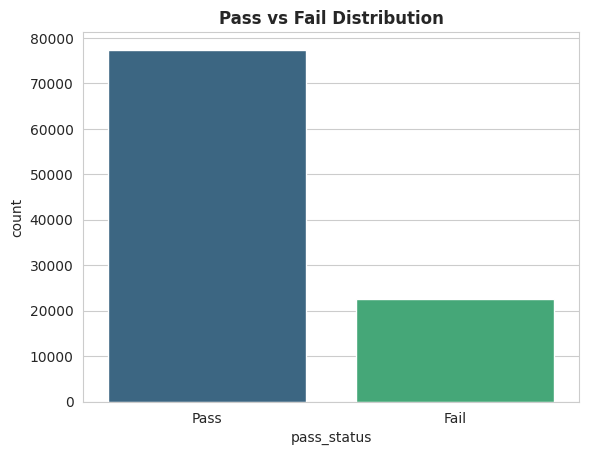

In [5]:
# Target distribution
print(df['pass_status'].value_counts())
print(df['pass_status'].value_counts(normalize=True).round(3))

sns.countplot(data=df, x='pass_status',hue='pass_status', palette='viridis')
plt.title("Pass vs Fail Distribution",fontweight='bold')
plt.show()

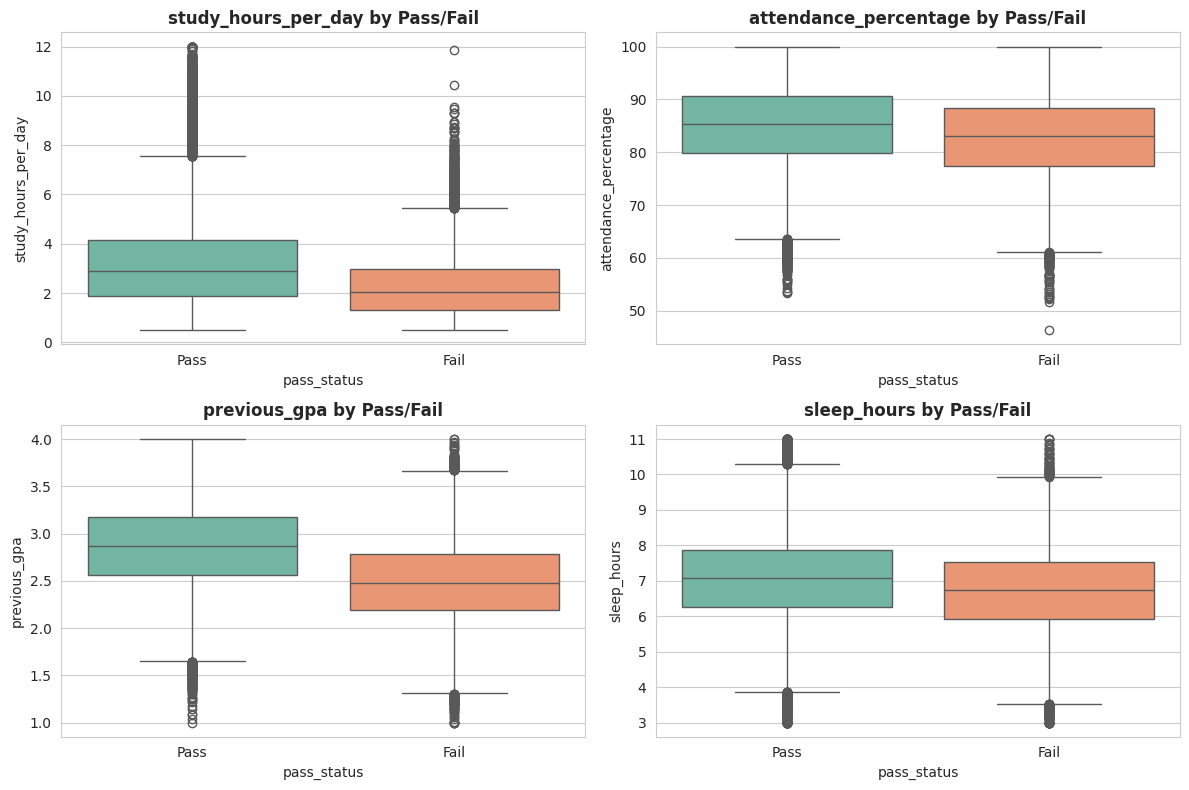

In [6]:
# A quick look at a few numeric study-habit features vs pass_status
num_features_preview = ['study_hours_per_day', 'attendance_percentage',
                         'previous_gpa', 'sleep_hours']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_features_preview):
    sns.boxplot(data=df, x='pass_status', y=col,hue='pass_status', ax=ax, palette='Set2')
    ax.set_title(f"{col} by Pass/Fail",fontweight='bold')
plt.tight_layout()
plt.show()

## **3. Important: Avoiding Data Leakage**

Before modeling, we must check **how the target was created**. Let's verify the relationship between `exam_score`, `questions_correct`/`questions_attempted`, and `pass_status`.

In [7]:
df['accuracy_ratio'] = df['questions_correct'] / df['questions_attempted']
print("Correlation of accuracy_ratio with exam_score:",
      round(df['accuracy_ratio'].corr(df['exam_score']), 3))
print("Correlation of questions_correct with exam_score:",
      round(df['questions_correct'].corr(df['exam_score']), 3))

print("\nexam_score range by pass_status:")
print(df.groupby('pass_status')['exam_score'].agg(['min', 'max']))

Correlation of accuracy_ratio with exam_score: 0.995
Correlation of questions_correct with exam_score: 0.975

exam_score range by pass_status:
              min     max
pass_status              
Fail          0.0   49.99
Pass         50.0  100.00


**Finding:** `exam_score` is almost perfectly determined by `questions_correct`/`questions_attempted` (correlation ≈ 0.99), and `pass_status` is simply `exam_score >= 50`.

If we keep `exam_score`, `questions_correct`, `questions_attempted`, `performance_grade`, or `performance_level` as features, the model would just be "cheating" by reading the answer directly (**data leakage**) instead of learning real patterns.

**We drop all of these** and instead predict `pass_status` purely from **study habits, lifestyle, and demographic features** — a much more realistic and useful ML problem.

In [8]:
leakage_cols = ['exam_score', 'questions_correct', 'questions_attempted',
                 'performance_grade', 'performance_level',
                 'accuracy_ratio', 'student_id']

df_model = df.drop(columns=leakage_cols)

target = 'pass_status'
X = df_model.drop(columns=[target])
y = df_model[target].map({'Pass': 1, 'Fail': 0})   # 1 = Pass, 0 = Fail

print("Features used:", X.shape[1])
print("Target balance:\n", y.value_counts(normalize=True).round(3))

Features used: 37
Target balance:
 pass_status
1    0.774
0    0.226
Name: proportion, dtype: float64


## **4. Train/Test Split & Preprocessing Pipeline**

- Numeric columns → fill missing values with the median, then scale.
- Categorical columns → fill missing values with the most frequent value, then one-hot encode.

Using a `Pipeline` + `ColumnTransformer` keeps preprocessing consistent and prevents leakage between train and test sets.

In [9]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns ({len(num_cols)}):", num_cols)
print(f"\nCategorical columns ({len(cat_cols)}):", cat_cols)

Numeric columns (19): ['age', 'previous_exam_score', 'previous_gpa', 'attendance_percentage', 'assignment_completion_rate', 'study_hours_per_day', 'self_study_hours', 'private_tuition', 'online_learning_hours', 'practice_tests_completed', 'sleep_hours', 'daily_screen_time', 'physical_activity_hours', 'stress_level', 'internet_access', 'online_course_hours', 'exam_preparation_days', 'time_management_score', 'exam_anxiety_level']

Categorical columns (18): ['gender', 'education_level', 'school_type', 'family_income', 'parent_education', 'urban_rural', 'class_participation', 'study_consistency', 'study_environment', 'study_method', 'revision_frequency', 'notes_quality', 'sleep_quality', 'break_frequency', 'motivation_level', 'device_availability', 'educational_app_usage', 'exam_difficulty']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (80000, 37)  Test shape: (20000, 37)


## **5. A Helper Function to Train & Evaluate Any Model**

To keep the code clean (and beginner-friendly), we write one function that trains a model, evaluates it, and stores the results for comparison.

In [11]:
results = {}

def train_and_evaluate(name, model):
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    results[name] = metrics

    print(f"--- {name} ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    return pipe, y_pred, y_prob

## **6. Baseline Model — Logistic Regression**

A simple, interpretable linear model. This gives us a benchmark score every other model must beat.

In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
pipe_lr, pred_lr, prob_lr = train_and_evaluate("Logistic Regression", log_reg)

--- Logistic Regression ---
Accuracy: 0.8473
Precision: 0.8757
Recall: 0.9355
F1-Score: 0.9046
ROC-AUC: 0.8922


## **7. Random Forest Classifier**

An ensemble of decision trees that usually improves over a linear baseline by capturing non-linear relationships.

In [13]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    random_state=RANDOM_STATE, n_jobs=-1
)
pipe_rf, pred_rf, prob_rf = train_and_evaluate("Random Forest", rf)

--- Random Forest ---
Accuracy: 0.8358
Precision: 0.8410
Recall: 0.9716
F1-Score: 0.9016
ROC-AUC: 0.8883


## **8. XGBoost Classifier (Top Performer)**

A gradient-boosted tree model — typically the strongest performer for structured/tabular data like this dataset.

In [14]:
xgb = XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
)
pipe_xgb, pred_xgb, prob_xgb = train_and_evaluate("XGBoost", xgb)

--- XGBoost ---
Accuracy: 0.8554
Precision: 0.8835
Recall: 0.9366
F1-Score: 0.9093
ROC-AUC: 0.9026


## **9. Model Comparison**

Now let's compare all three models side by side.

In [15]:
results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
results_df.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost,0.8554,0.8835,0.9366,0.9093,0.9026
Logistic Regression,0.8473,0.8757,0.9355,0.9046,0.8922
Random Forest,0.8358,0.8410,0.9716,0.9016,0.8883


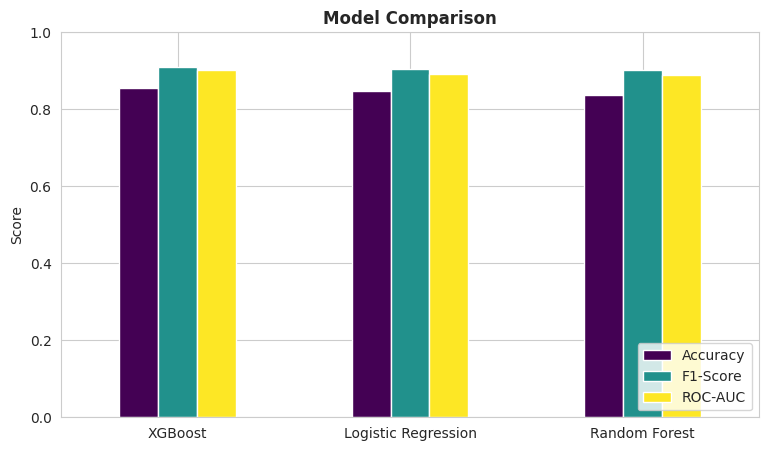

In [16]:
results_df[['Accuracy', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', figsize=(9, 5), colormap='viridis'
)
plt.title("Model Comparison",fontweight='bold')
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

Best model: XGBoost


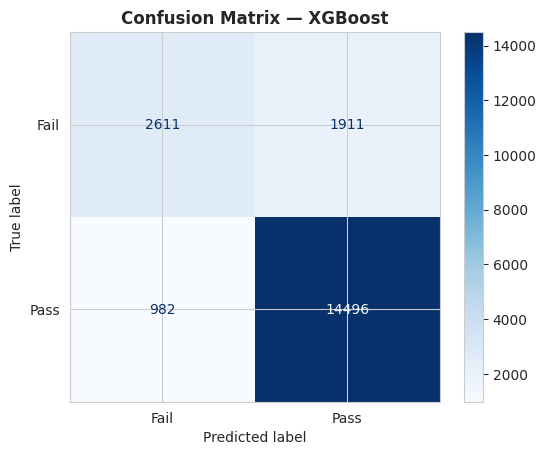

In [17]:
best_model_name = results_df['ROC-AUC'].idxmax()
best_pipe = {'Logistic Regression': pipe_lr, 'Random Forest': pipe_rf, 'XGBoost': pipe_xgb}[best_model_name]
best_prob = {'Logistic Regression': prob_lr, 'Random Forest': prob_rf, 'XGBoost': prob_xgb}[best_model_name]
best_pred = {'Logistic Regression': pred_lr, 'Random Forest': pred_rf, 'XGBoost': pred_xgb}[best_model_name]

print("Best model:", best_model_name)

# Confusion matrix for the best model
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Fail', 'Pass'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix — {best_model_name}",fontweight='bold')
plt.show()

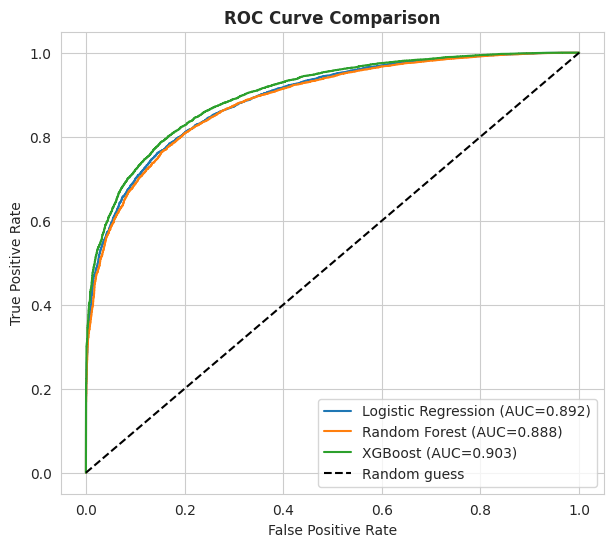

In [18]:
# ROC curves for all models
plt.figure(figsize=(7, 6))
for name, prob in [('Logistic Regression', prob_lr), ('Random Forest', prob_rf), ('XGBoost', prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = results[name]['ROC-AUC']
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison",fontweight='bold')
plt.legend()
plt.show()

## **10. Feature Importance (Best Model)**

Which factors matter most for predicting whether a student passes?

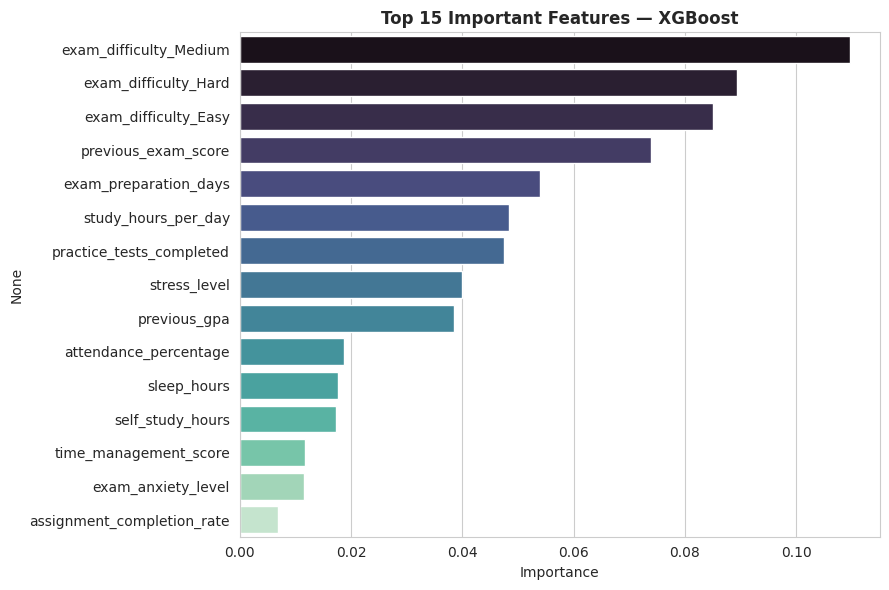

In [19]:
feature_names = (num_cols +
    list(best_pipe.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(cat_cols)))

if best_model_name == 'Logistic Regression':
    importances = np.abs(best_pipe.named_steps['classifier'].coef_[0])
else:
    importances = best_pipe.named_steps['classifier'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index,hue=feat_imp.index, palette='mako')
plt.title(f"Top 15 Important Features — {best_model_name}",fontweight='bold')
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## **11. Conclusion**

- **Data leakage check was critical**: `exam_score`, `questions_correct`/`attempted`, and the derived grade/level columns had to be removed, since `pass_status` is a direct threshold of `exam_score`. Keeping them would have given a fake ~100% accuracy.
- After removing leaky columns, we predicted `pass_status` using genuine **study habits, attendance, sleep, prior academic performance, and demographic** features.
- We trained three models from baseline to advanced:
  - **Logistic Regression** (simple, interpretable baseline)
  - **Random Forest** (non-linear ensemble)
  - **XGBoost** (gradient boosting, best performer on tabular data)
- The comparison table and ROC curves show the best-performing model (see Section 9), which we then used for confusion matrix and feature importance analysis.
- The most influential factors tend to be things like **previous academic performance (previous_gpa, previous_exam_score), attendance percentage, and study consistency** — all of which are actionable levers for students and educators, unlike the leaked "answer" columns.
- **Next steps** for further improvement: hyperparameter tuning (GridSearchCV/Optuna), handling class imbalance with SMOTE, trying stacked ensembles, and collecting more behavioral features over time.